In [ ]:
#Vamos a crear una tabla
import pandas as pd

x_list=[1,2,2,3,4,4,5,6]
y_list=[2,3,4,4,4,6,5,7]

#Diccionario
dicc={'x':x_list,'y':y_list}

#Dataframe
df=pd.DataFrame(dicc)

df

,x,y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,6
6,5,5
7,6,7


In [ ]:
#Vamos a agregar la columna xy
df['xy']=df['x']*df['y']
df

,x,y,xy
0,1,2,2
1,2,3,6
2,2,4,8
3,3,4,12
4,4,4,16
5,4,6,24
6,5,5,25
7,6,7,42


In [ ]:
#Ahora la columna x a la 2
df['x2']=df['x']**2
df

,x,y,xy,x2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36


In [ ]:
#Vamos a sumar las columnas
suma_columnas = df[['x', 'y', 'xy', 'x2']].sum()

# Creamos un DataFrame con esta suma para poder añadirlo como una fila
suma_df = pd.DataFrame([suma_columnas], columns=df.columns)

# Concatenamos el DataFrame original con la fila de sumas
df = pd.concat([df, suma_df], ignore_index=True)

# Mostramos el DataFrame resultante
df

,x,y,xy,x2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36
8,27,35,135,111


In [ ]:
#Sacar la cantidad de datos
n=len(x_list)
print('Cantidad de datos:',n)
#Vamos a crear las variables de cada sumatoria
sum_x=df.loc[8,'x']
print('Sumatoria de x:',sum_x)
sum_y=df.loc[8,'y']
print('Sumatoria de y:',sum_y)
sum_xy=df.loc[8,'xy']
print('Sumatoria de xy:',sum_xy)
sum_x2=df.loc[8,'x2']
print('Sumatoria de x2:',sum_x2)

Cantidad de datos: 8
Sumatoria de x: 27
Sumatoria de y: 35
Sumatoria de xy: 135
Sumatoria de x2: 111


In [ ]:
#Calculamos la pendiente
numerador=n*sum_xy-sum_x*sum_y
denominador=n*sum_x2-sum_x**2
m=round(numerador/denominador,3)
print('Pendiente:',m)

Pendiente: 0.849


In [ ]:
#Calculamos el intercepto
prom_x=sum_x/n
prom_y=sum_y/n
b=round(prom_y-m*prom_x,3)
print('Intercepto:',b)

Intercepto: 1.51


In [ ]:
#Ecuación de regresión Lineal
print("y=",m,"*x","+",b)

y= 0.849 *x + 1.51


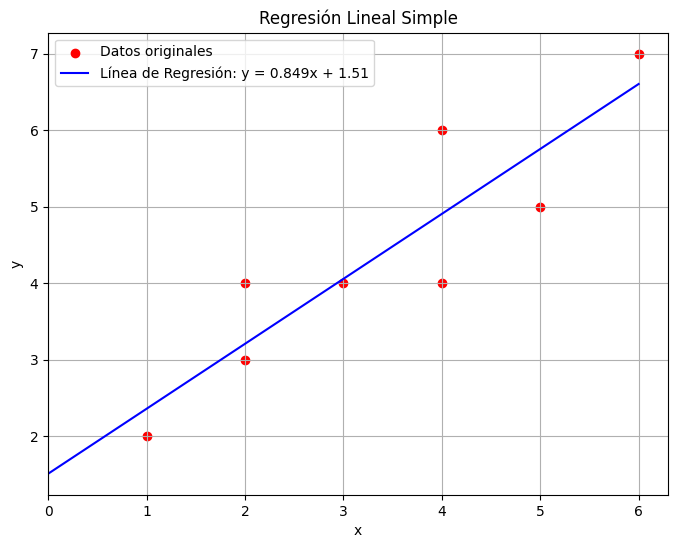

In [ ]:
#La gráfica es
import matplotlib.pyplot as plt
import numpy as np

# Puntos de datos originales
x_data = np.array(x_list)
y_data = np.array(y_list)

# Rango para la línea de regresión (para incluir x=0 y mostrar el intercepto)
x_line = np.array([0, x_data.max()])
y_line = m * x_line + b

# Crear la gráfica
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, label='Datos originales', color='red')
plt.plot(x_line, y_line, color='blue', label=f'Línea de Regresión: y = {m}x + {b}')

plt.title('Regresión Lineal Simple')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.xlim(left=0) # Establece el límite izquierdo del eje x en 0
plt.show()

In [ ]:
#Cuando x=6 cuanto vale y?
y=round(m*6+b,3)
print("y=",y)

y= 6.604


In [ ]:
#¿Cuál es el valor de Sr?
Sr=round(np.sum((y_data-(m*x_data+b))**2),3)
print("Sr=",Sr)

Sr= 3.547


In [ ]:
#Calcular el Sr por medio de tabla
df['y_pred']=(m*df['x'])+b
df

,x,y,xy,x2,y_pred
0,1,2,2,1,2.359
1,2,3,6,4,3.208
2,2,4,8,4,3.208
3,3,4,12,9,4.057
4,4,4,16,16,4.906
5,4,6,24,16,4.906
6,5,5,25,25,5.755
7,6,7,42,36,6.604
8,27,35,135,111,24.433


In [ ]:
#Debemos quitar la última fila del total
df=df.drop(df.index[-1])
df

,x,y,xy,x2,y_pred
0,1,2,2,1,2.359
1,2,3,6,4,3.208
2,2,4,8,4,3.208
3,3,4,12,9,4.057
4,4,4,16,16,4.906
5,4,6,24,16,4.906
6,5,5,25,25,5.755
7,6,7,42,36,6.604


In [ ]:
#Calculamos el error de los datos y-ypred
df['error']=df['y']-df['y_pred']
df

,x,y,xy,x2,y_pred,error
0,1,2,2,1,2.359,-0.359
1,2,3,6,4,3.208,-0.208
2,2,4,8,4,3.208,0.792
3,3,4,12,9,4.057,-0.057
4,4,4,16,16,4.906,-0.906
5,4,6,24,16,4.906,1.094
6,5,5,25,25,5.755,-0.755
7,6,7,42,36,6.604,0.396


In [ ]:
#Luego error al cuadrado
df['error2']=df['error']**2
df

,x,y,xy,x2,y_pred,error,error2
0,1,2,2,1,2.359,-0.359,0.128881
1,2,3,6,4,3.208,-0.208,0.043264
2,2,4,8,4,3.208,0.792,0.627264
3,3,4,12,9,4.057,-0.057,0.003249
4,4,4,16,16,4.906,-0.906,0.820836
5,4,6,24,16,4.906,1.094,1.196836
6,5,5,25,25,5.755,-0.755,0.570025
7,6,7,42,36,6.604,0.396,0.156816


In [ ]:
#Calculamos el sr:suma de los errores al cuadrado
Sr_t=round(sum(df['error2']),3)
print(Sr_t)

3.547


In [ ]:
#Promedio MSE
MSE=round(Sr_t/n,3)
print(MSE)

0.443


In [ ]:
#Raiz cuadrada RMSE
RMSE=round(MSE**0.5,3)
print(RMSE)

0.666


In [ ]:
#Ahora vamos hacerlo con valor absoluto
df['error_abs']=abs(df['error'])
df

,x,y,xy,x2,y_pred,error,error2,error_abs
0,1,2,2,1,2.359,-0.359,0.128881,0.359
1,2,3,6,4,3.208,-0.208,0.043264,0.208
2,2,4,8,4,3.208,0.792,0.627264,0.792
3,3,4,12,9,4.057,-0.057,0.003249,0.057
4,4,4,16,16,4.906,-0.906,0.820836,0.906
5,4,6,24,16,4.906,1.094,1.196836,1.094
6,5,5,25,25,5.755,-0.755,0.570025,0.755
7,6,7,42,36,6.604,0.396,0.156816,0.396


In [ ]:
#Calculamos la suma de los errores en valor absoluto (SAE)
SAE = round(sum(df['error_abs']),3)
print(f"SAE = {SAE}")

SAE = 4.567


In [ ]:
MAE=round(SAE/n,3)
print(f"MAE = {MAE}")


MAE = 0.571
